In [8]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent, GreedyAgent
from ant.decentralised.special_strategies import EgalitarianAgent, PettyAgent, ImitationAgent, SatisficingAgent
from ant.centralised import P4

In [9]:
market_size = 20
simulation_length = 400
num_repeats = 30

graph_types = ["complete", "random", "grid", "scale-free", "Small-World"]

strategies = {
    "Proportional": ProportionalAgent,
    "Greedy": GreedyAgent,
    # "Egalitarian": EgalitarianAgent,
    # "Petty": PettyAgent,
    # "Imitation": ImitationAgent,
    # "Satisficing": SatisficingAgent
}

# Dictionary to store all simulation results across the repeats
# Format: all_results[strategy][graph_type] = list of 10 simulation result arrays
all_results = {strategy: {gtype: [] for gtype in graph_types} for strategy in strategies}

In [10]:
for repeat in range(num_repeats):
    print(f"Running repeat {repeat + 1}/{num_repeats}...")

    current_seed = 657849724 + repeat
    
    rnd_seed = current_seed
    random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)
    while not nx.is_connected(random_graph):
        rnd_seed += 1000  
        random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)
    
    graphs = {
        "complete": nx.complete_graph(market_size),
        "random": random_graph,
        "grid" : nx.convert_node_labels_to_integers(nx.grid_2d_graph(int(market_size / 4), 4)),
        "scale-free" : nx.barabasi_albert_graph(market_size, 1, seed=current_seed),
        "Small-World": nx.connected_watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=current_seed),
    }

    for graph_type, graph in graphs.items():
        for strategy_name, strategy_cls in strategies.items():
            _market = Market(market_size, graph=graph, seed=current_seed, agent_type=strategy_cls)
            optimal_aloc, utility_vec = P4(_market)
            _market.set_market_equilibrium(optimal_aloc, utility_vec)
            
            simulated_state = _market.simulate(simulation_length)
            all_results[strategy_name][graph_type].append(simulated_state)

Running repeat 1/30...
Running repeat 2/30...
Running repeat 3/30...
Running repeat 4/30...
Running repeat 5/30...
Running repeat 6/30...
Running repeat 7/30...
Running repeat 8/30...
Running repeat 9/30...
Running repeat 10/30...
Running repeat 11/30...
Running repeat 12/30...
Running repeat 13/30...
Running repeat 14/30...
Running repeat 15/30...
Running repeat 16/30...
Running repeat 17/30...
Running repeat 18/30...
Running repeat 19/30...
Running repeat 20/30...
Running repeat 21/30...
Running repeat 22/30...
Running repeat 23/30...
Running repeat 24/30...
Running repeat 25/30...
Running repeat 26/30...
Running repeat 27/30...
Running repeat 28/30...
Running repeat 29/30...
Running repeat 30/30...


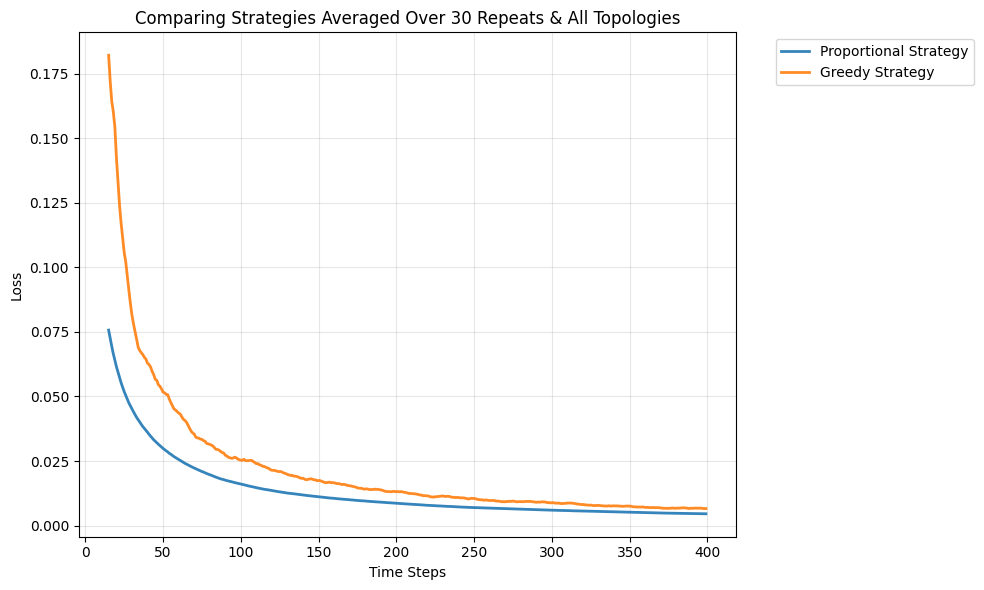

In [11]:
training_period = 15
time_steps = np.arange(training_period, simulation_length)

plt.figure(figsize=(10, 6))

for strategy_name in strategies.keys():
    all_topologies_average = []
    
    for graph_type in graph_types:
        states_array = np.array(all_results[strategy_name][graph_type])
        
        # Calculate the average loss per timestep across the repeats
        avg_state = np.mean(states_array, axis=0)
        all_topologies_average.append(avg_state)

    # Calculate the grand average per timestep over ALL topologies and repeats for THIS strategy
    grand_average = np.mean(all_topologies_average, axis=0)
    
    plt.plot(
        time_steps,
        grand_average[training_period:],
        label=f"{strategy_name} Strategy",
        linewidth=2,
        alpha=0.9
    )

plt.xlabel("Time Steps")
plt.ylabel("Loss")
plt.title(f"Comparing Strategies Averaged Over {num_repeats} Repeats & All Topologies")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

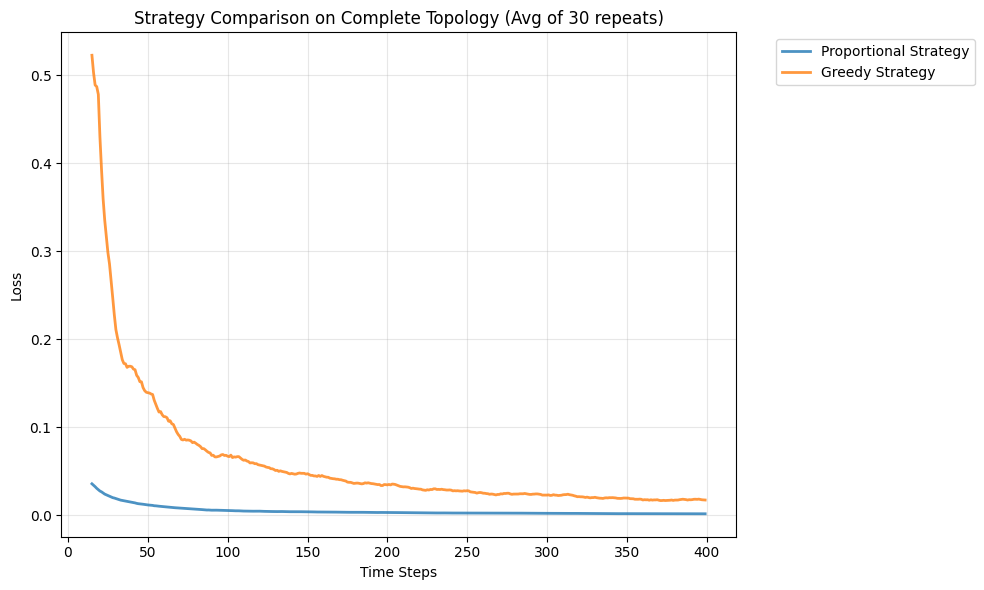

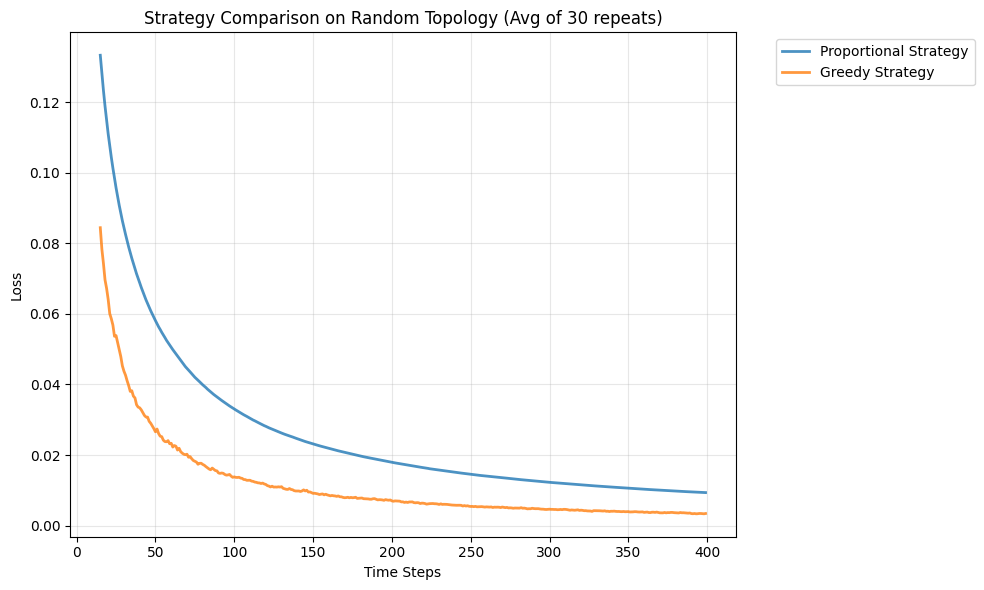

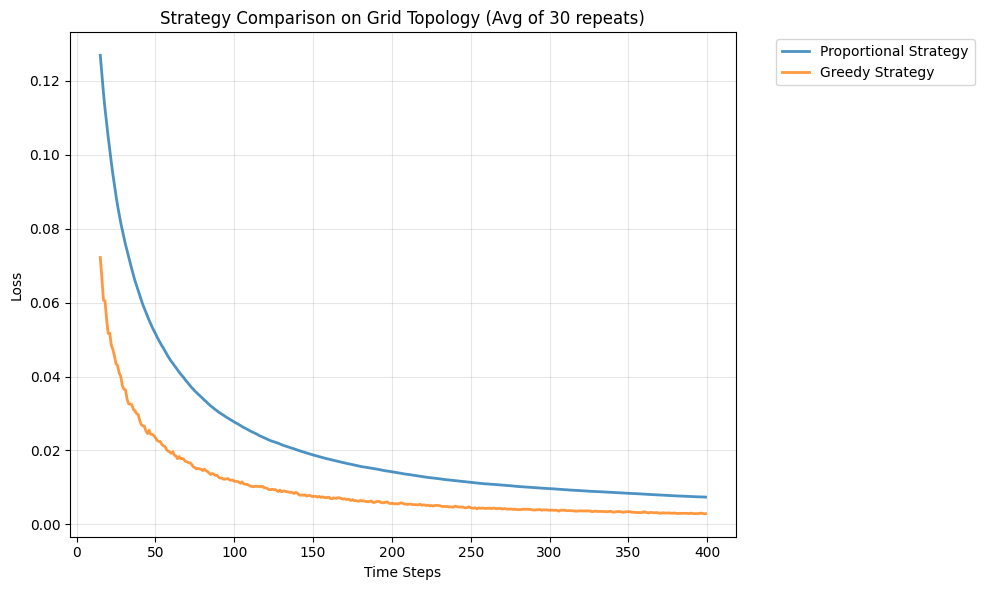

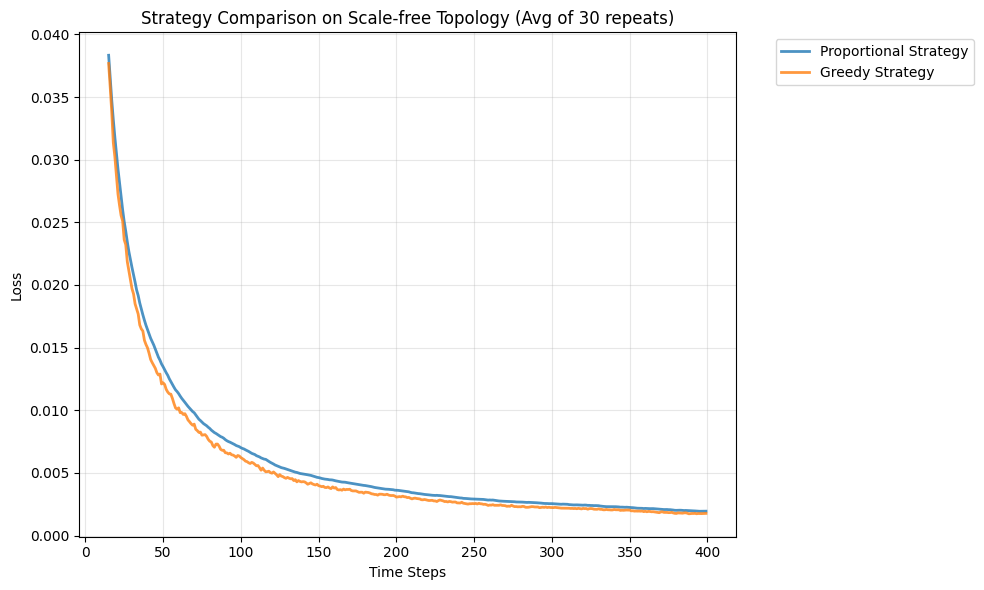

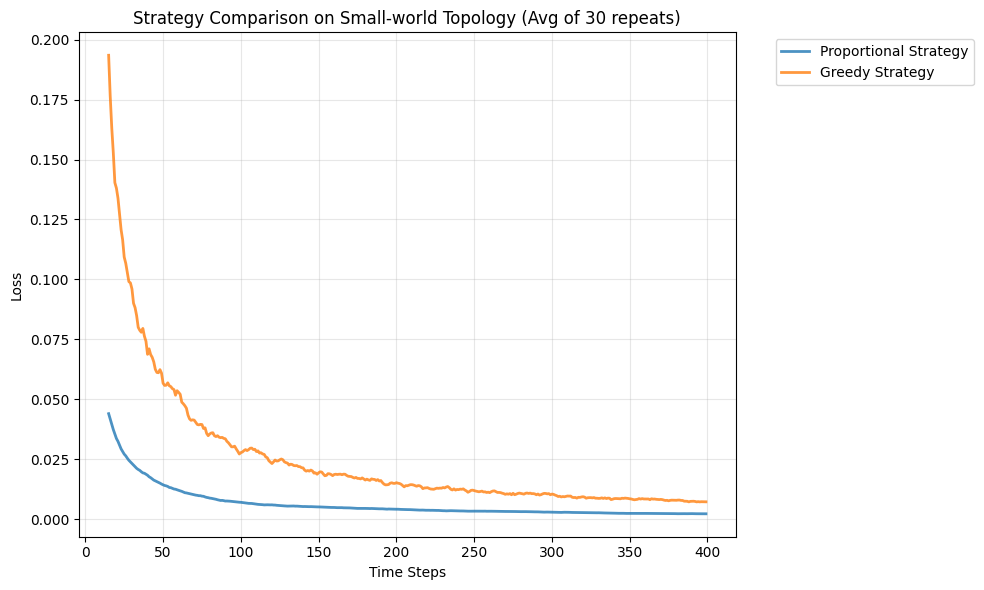

In [12]:
# Visualize the performance of each strategy independently for EACH graph type
for graph_type in graph_types:
    plt.figure(figsize=(10, 6))
    
    for strategy_name in strategies.keys():
        states_array = np.array(all_results[strategy_name][graph_type])
        
        # Calculate the average loss per timestep across the repeats for this specific graph type and strategy
        avg_state = np.mean(states_array, axis=0)
        
        plt.plot(
            time_steps,
            avg_state[training_period:],
            label=f"{strategy_name} Strategy",
            linewidth=2,
            alpha=0.8
        )

    plt.xlabel("Time Steps")
    plt.ylabel("Loss")
    plt.title(f"Strategy Comparison on {graph_type.capitalize()} Topology (Avg of {num_repeats} repeats)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [13]:
# Create a summary table of average loss per strategy across all topologies
summary_data = []

for strategy_name in strategies.keys():
    all_topologies_average = []
    
    for graph_type in graph_types:
        states_array = np.array(all_results[strategy_name][graph_type])
        avg_state = np.mean(states_array, axis=0)
        all_topologies_average.append(avg_state)
    
    # Calculate grand average loss for this strategy
    grand_average = np.mean(all_topologies_average, axis=0)
    final_avg_loss = np.mean(grand_average[training_period:])
    
    summary_data.append({
        'Strategy': strategy_name,
        'Average Loss after 400 iterations': final_avg_loss
    })

summary_df = pd.DataFrame(summary_data).sort_values('Average Loss after 400 iterations')
print(summary_df.to_string(index=False))

    Strategy  Average Loss after 400 iterations
Proportional                           0.013223
      Greedy                           0.022372
